In [94]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


In [95]:
train_df=pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

In [96]:
print(f"Train dataset shape: {train_df.shape}");
print(f"Test dataset shape: {test_df.shape}");

Train dataset shape: (7000, 6)
Test dataset shape: (1700, 5)


In [97]:
print(train_df.head())
print(train_df.columns)

   id                                             phrase  feature_1  \
0   0  It may as well be called `` Jar-Jar Binks : Th...       14.0   
1   1                               You have to see it .        6.0   
2   2  ... either you 're willing to go with this cla...       16.0   
3   3  Watching Harris ham it up while physically and...       37.0   
4   4  Pete 's screenplay manages to find that real n...       20.0   

   feature_2  feature_3  sentiment  
0        5.0        7.0          0  
1        1.0        NaN          2  
2        0.0        6.0          1  
3        NaN        3.0          1  
4        1.0        4.0          2  
Index(['id', 'phrase', 'feature_1', 'feature_2', 'feature_3', 'sentiment'], dtype='object')


In [98]:
train_df.isnull().sum()

id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

In [99]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


**DESCRIPTIVE STATISTICS OF NUMERICAL COLUMNS**

In [100]:
feature_columns = ['feature_1', 'feature_2', 'feature_3']
desc = train_df[feature_columns].describe()
print(desc)

         feature_1    feature_2    feature_3
count  6088.000000  5896.000000  5938.000000
mean     19.025624     1.996608     3.334119
std       9.303562     1.634858     2.321154
min       1.000000     0.000000     0.000000
25%      12.000000     1.000000     2.000000
50%      18.000000     1.000000     3.000000
75%      25.000000     3.000000     4.000000
max      52.000000    19.000000    19.000000


**Filling missing values**

In [101]:
feature_columns = ['feature_1', 'feature_2', 'feature_3']

for col in feature_columns:
    value=train_df[col].median()
    train_df[col] = train_df[col].fillna(value)
    test_df[col]=test_df[col].fillna(value)
    

print("Null values in train dataset :\n ",train_df.isnull().sum())
print('\n')
print("Null values in test dataset :\n",test_df.isnull().sum())

Null values in train dataset :
  id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64


Null values in test dataset :
 id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
dtype: int64


**HANDLING DUPLICATES**

In [102]:
duplicate_values = train_df.duplicated().sum()
print("Duplicate Values In Train Dataset : ",duplicate_values)

Duplicate Values In Train Dataset :  0


**OUTLIER DETECTION**

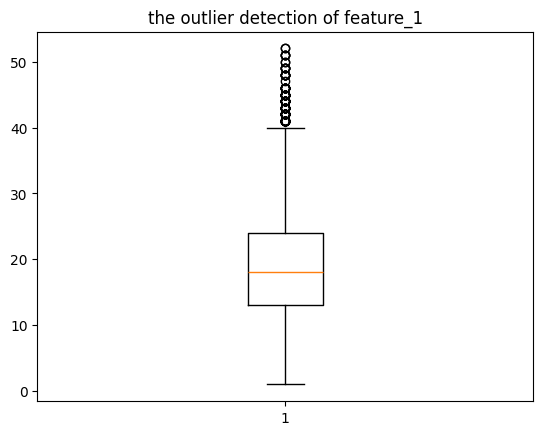

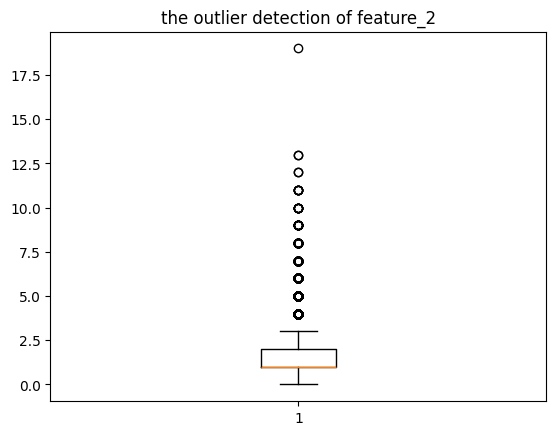

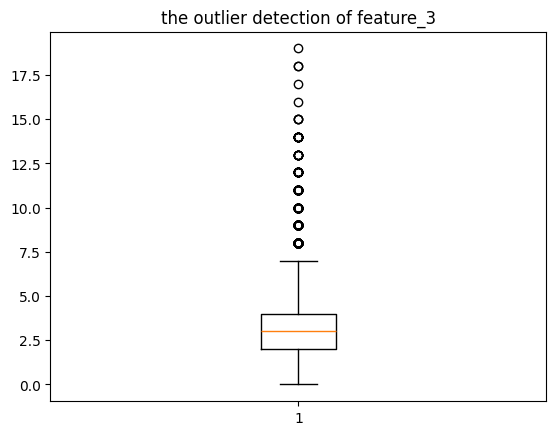

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in feature_columns:
    data = train_df[col]
    plt.boxplot(data)
    plt.title(f"the outlier detection of {col}")
    plt.show()

**VISUALIZATIONS**

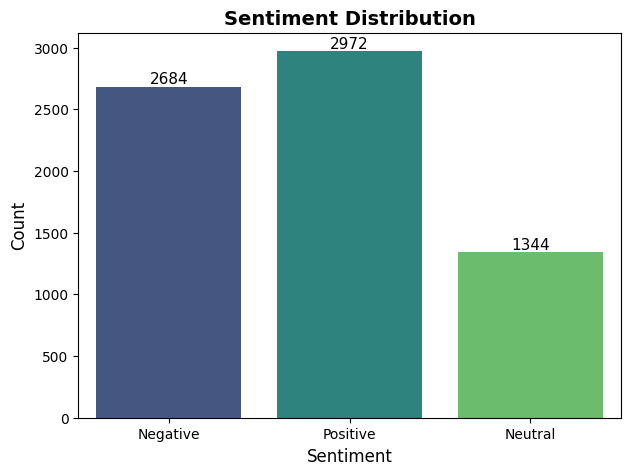

In [104]:
# Visualisaiton 1

import seaborn as sns
import matplotlib.pyplot as plt

sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
train_df['sentiment_label']=train_df['sentiment'].map(sentiment_map)


plt.figure(figsize=(7,5))

ax = sns.countplot(x='sentiment_label', hue='sentiment_label', data=train_df, palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)


plt.title("Sentiment Distribution", fontsize=14, weight='bold')
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)


# plt.xticks(fontsize=11)
# plt.yticks(fontsize=10)
# sns.despine()

# plt.tight_layout()
plt.show()

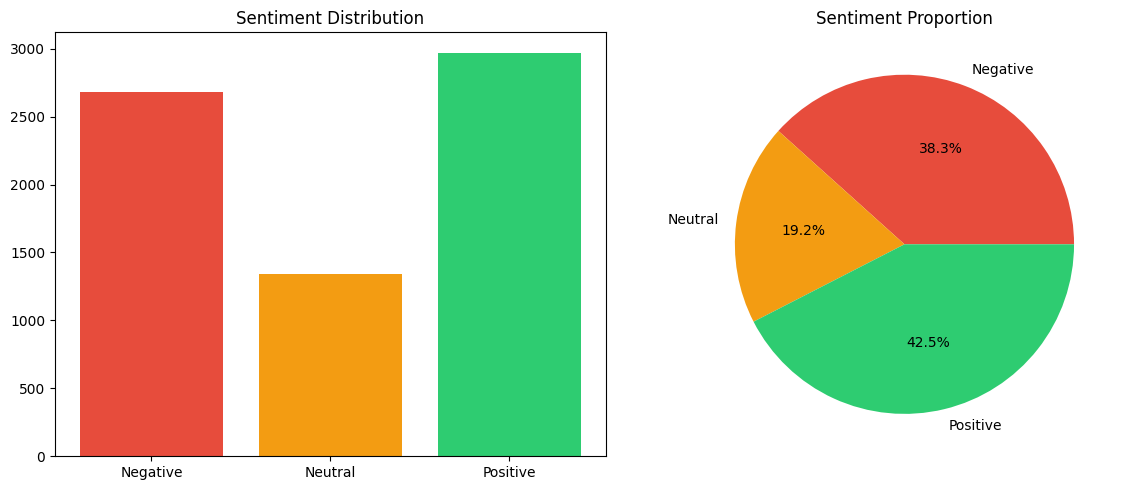

In [105]:
# VISUALISATION 2 = Feature distribution by sentiments

import matplotlib.pyplot as plt

counts = train_df['sentiment'].value_counts().sort_index()


labels = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.bar(labels, counts, color=colors)
plt.title("Sentiment Distribution")


plt.subplot(1, 2, 2)
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Sentiment Proportion")

plt.tight_layout()
plt.show()

**VISUALISATION 2**

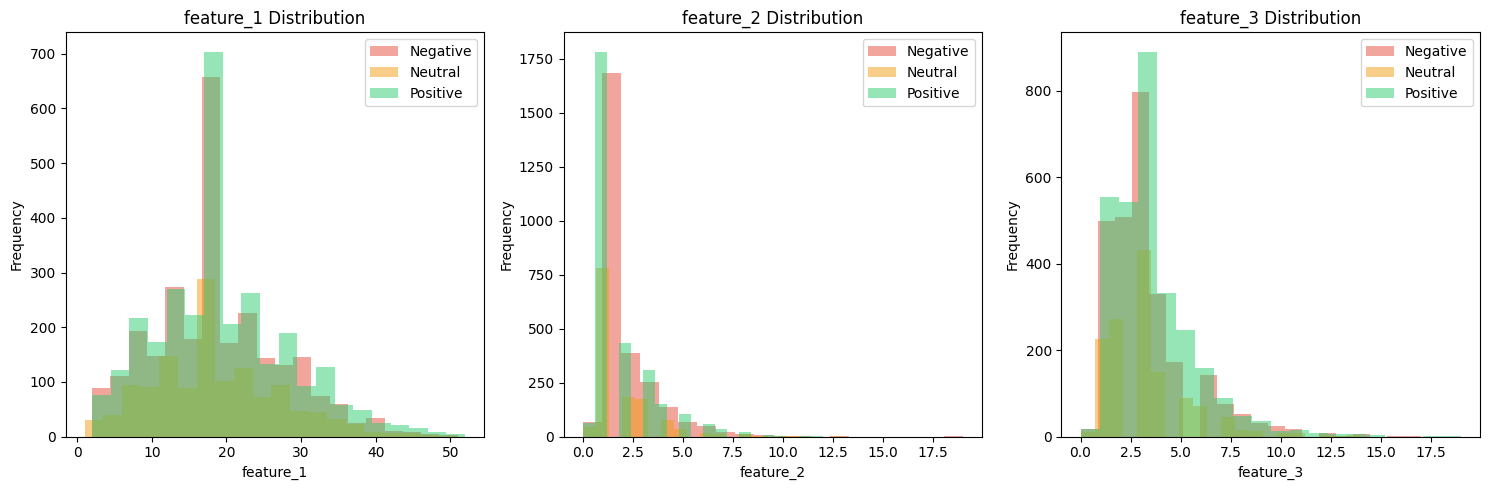

In [106]:
import matplotlib.pyplot as plt

labels = ['Negative', 'Neutral', 'Positive']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(15,5))

for i, col in enumerate(feature_columns):
    plt.subplot(1, len(feature_columns), i+1)
    
    for sent in [0, 1, 2]:
        data = train_df[train_df['sentiment'] == sent][col]
        plt.hist(data, bins=20, alpha=0.5, color=colors[sent], label=labels[sent])
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

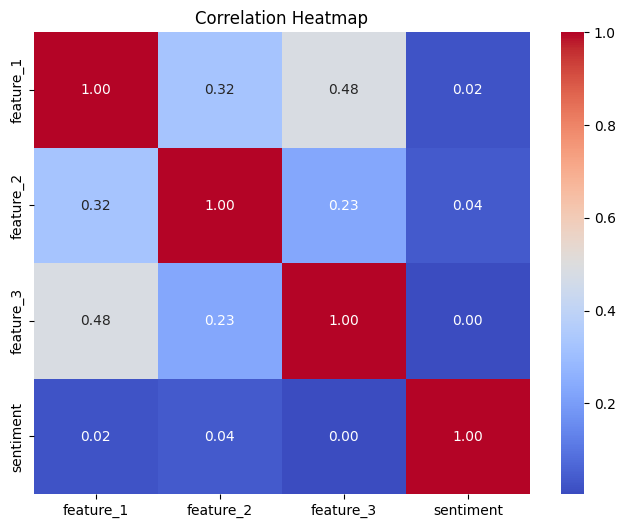

In [107]:
# visualisation 3 -- correlation heatmap
train_new=train_df.copy()
train_new=train_new.drop('id',axis=1)
corr = train_new.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

**FEATURE SCALING**

In [108]:
from sklearn.preprocessing import StandardScaler


feature_columns = ['feature_1', 'feature_2', 'feature_3']


X = train_df[feature_columns].copy()
y = train_df['sentiment'].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns)

In [109]:
X_scaled

,feature_1,feature_2,feature_3
0,-0.563431,2.047495,1.735891
1,-1.484823,-0.543802,-0.132380
2,-0.333083,-1.191627,1.268823
3,2.085571,-0.543802,-0.132380
4,0.127613,-0.543802,0.334687
...,...,...,...
6995,2.546267,0.751846,-0.132380
6996,2.085571,0.104022,3.604162
6997,-0.908953,-0.543802,-0.599448
6998,0.242787,-0.543802,-0.599448


**Dataset splitting**

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val=train_test_split(X, y, test_size=0.2, random_state=42)



**MODEL BUILDING**

In [111]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

In [112]:
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'SGD Classifier'        : SGDClassifier(random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(random_state=42),
    'SVM'                   : SVC(kernel='rbf', random_state=42),
    'KNN'                   : KNeighborsClassifier(n_neighbors=5),
    'AdaBoost'              : AdaBoostClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(random_state=42),
    'Gaussian NB'           : GaussianNB(),
    'Dummy Classifier'      : DummyClassifier(strategy='most_frequent'),
    'XGBoost'               : XGBClassifier(eval_metric='mlogloss', random_state=42)
}

In [113]:
from sklearn.metrics import accuracy_score

results={}
for name, model in models.items():
    model.fit(X_train,y_train)
    prediction=model.predict(X_val)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    accuracy = accuracy_score(y_val,prediction)
    results[name] = {'model': model, 'train_acc': train_acc, 'val_acc': accuracy}
    print(f'{name:<25} {train_acc:>10.4f} {accuracy:>10.4f}')

Logistic Regression           0.4288     0.4143
SGD Classifier                0.3875     0.3757
Decision Tree                 0.5900     0.3850
SVM                           0.4275     0.4129
KNN                           0.5038     0.3836
AdaBoost                      0.4291     0.4143
Random Forest                 0.5900     0.3907
Gradient Boosting             0.4825     0.3879
Gaussian NB                   0.4093     0.4064
Dummy Classifier              0.4275     0.4129
XGBoost                       0.5507     0.3864


**HYPER-PARAMETER TUNING ON 3 MODELS**

In [114]:
# hyperparameter tuning for : LOGISTIC REGRESSION

from sklearn.model_selection import GridSearchCV
params_grid={
    'C':[0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
}


gs_cv_lr=GridSearchCV(
    LogisticRegression(max_iter=1000,random_state=42),
    params_grid, cv=5, scoring = 'accuracy', n_jobs=-1
)

gs_cv_lr.fit(X_train,y_train)
print(f"best parameters are: {gs_cv_lr.best_params_}")
print(f'best cv score : {gs_cv_lr.best_score_ :.4f}')
tuned_model_accuracy = accuracy_score(y_val, gs_cv_lr.best_estimator_.predict(X_val))
print(f'validation accuracy (tuned): {tuned_model_accuracy:.4f}')


best parameters are: {'C': 1, 'solver': 'liblinear'}
best cv score : 0.4291
validation accuracy (tuned): 0.4143


In [115]:
# hyper-parameter tuning for : RandomForest
params_grid={
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 5, 10],
    'min_samples_split' : [2, 5]
}

gs_cv_rf= GridSearchCV(
    RandomForestClassifier(random_state=42),
    params_grid, cv=5, scoring='accuracy', n_jobs=-1
)

gs_cv_rf.fit(X_train, y_train)
print(f"best parameter are for RF : {gs_cv_rf.best_params_}")
print(f"best CV score : {gs_cv_rf.best_score_:.4f}")
tuned_rf_acc = accuracy_score(y_val, gs_cv_rf.best_estimator_.predict(X_val))
print(f'Validation Accuracy (tuned): {tuned_rf_acc:.4f}')

best parameter are for RF : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
best CV score : 0.4302
Validation Accuracy (tuned): 0.4071


In [116]:
# hyper-parameter tuning in XGBOOST 

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
}
gs_cv_xgb = GridSearchCV(XGBClassifier(eval_metric='mlogloss'),
                      param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
gs_cv_xgb.fit(X_train, y_train)
print(f'Best Params: {gs_cv_xgb.best_params_}')
print(f'Best CV Score: {gs_cv_xgb.best_score_:.4f}')
tuned_xgb_acc = accuracy_score(y_val, gs_cv_xgb.best_estimator_.predict(X_val))
print(f'Validation Accuracy (tuned): {tuned_xgb_acc:.4f}')

Best Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50}
Best CV Score: 0.4329
Validation Accuracy (tuned): 0.4171


**model performance comparison**

In [117]:
comparison = pd.DataFrame([
    {'Model': name, 'Train Accuracy': r['train_acc'], 'Val Accuracy': r['val_acc'],
     'Tuned': False}
    for name, r in results.items()
])


tuned_rows = pd.DataFrame([
    {'Model': 'LR (Tuned)',  'Train Accuracy': accuracy_score(y_train, gs_cv_lr.best_estimator_.predict(X_train)),
     'Val Accuracy': tuned_model_accuracy,  'Tuned': True},
    {'Model': 'RF (Tuned)',  'Train Accuracy': accuracy_score(y_train, gs_cv_rf.best_estimator_.predict(X_train)),
     'Val Accuracy': tuned_rf_acc,  'Tuned': True},
    {'Model': 'XGB (Tuned)', 'Train Accuracy': accuracy_score(y_train, gs_cv_xgb.best_estimator_.predict(X_train)),
     'Val Accuracy': tuned_xgb_acc, 'Tuned': True},
])
comparison = pd.concat([comparison, tuned_rows], ignore_index=True)

print("MODEL COMPARISONS")

print(comparison.sort_values('Val Accuracy', ascending=False).to_string(index=False))

MODEL COMPARISONS
              Model  Train Accuracy  Val Accuracy  Tuned
        XGB (Tuned)        0.450000      0.417143   True
Logistic Regression        0.428750      0.414286  False
         LR (Tuned)        0.428393      0.414286   True
           AdaBoost        0.429107      0.414286  False
                SVM        0.427500      0.412857  False
   Dummy Classifier        0.427500      0.412857  False
         RF (Tuned)        0.446250      0.407143   True
        Gaussian NB        0.409286      0.406429  False
      Random Forest        0.590000      0.390714  False
  Gradient Boosting        0.482500      0.387857  False
            XGBoost        0.550714      0.386429  False
      Decision Tree        0.590000      0.385000  False
                KNN        0.503750      0.383571  False
     SGD Classifier        0.387500      0.375714  False


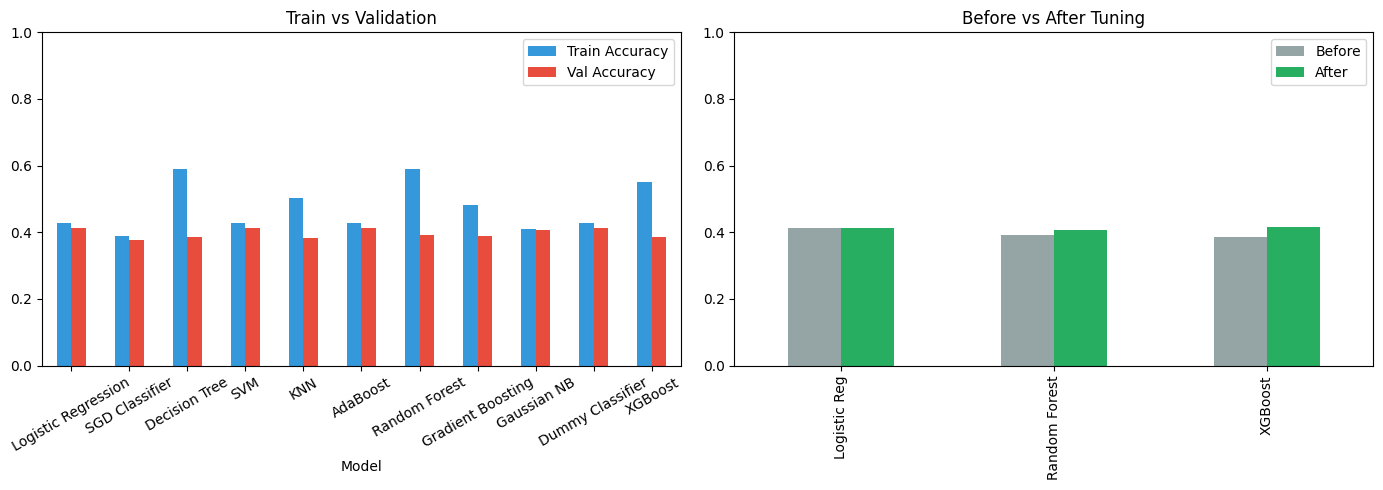

Best model: XGB (Tuned) (0.4171)


In [118]:
results_df = pd.DataFrame(list(models.items()), columns=["Model", "Accuracy"])

base = comparison[~comparison['Tuned']]

plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
base.set_index('Model')[['Train Accuracy','Val Accuracy']].plot(
    kind='bar', ax=plt.gca(), color=['#3498db','#e74c3c']
)
plt.title("Train vs Validation")
plt.ylim(0,1)
plt.xticks(rotation=30)


td = pd.DataFrame({
    'Before': [results['Logistic Regression']['val_acc'],
               results['Random Forest']['val_acc'],
               results['XGBoost']['val_acc']],
    'After':  [tuned_lr_acc, tuned_rf_acc, tuned_xgb_acc]
}, index=['Logistic Reg','Random Forest','XGBoost'])

plt.subplot(1,2,2)
td.plot(kind='bar', ax=plt.gca(), color=['#95a5a6','#27ae60'])
plt.title("Before vs After Tuning")
plt.ylim(0,1)

plt.tight_layout()
plt.show()


best = comparison.loc[comparison['Val Accuracy'].idxmax()]
print(f"Best model: {best['Model']} ({best['Val Accuracy']:.4f})")

**DETAILED CLASSIFICATION**

In [119]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_base = max(results.items(), key=lambda x: x[1]['val_acc'])
best_name, best_info = best_base
print(f'Classification Report for Best Base Model: {best_name}')
preds = best_info['model'].predict(X_val)
# test_preds = best_info['model'].predict(X_test)
print(classification_report(y_val, preds, zero_division=0))
# Confusion matrix
cm = confusion_matrix(y_val, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title(f'Confusion Matrix - {best_name}', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

Classification Report for Best Base Model: Logistic Regression


NameError: name 'X_test' is not defined

In [ ]:
submission = pd.DataFrame({
    'ID': test_df['id'],
    'class': test_preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

print("submission.csv created")
print(submission)
